In [ ]:
import math
from dataclasses import dataclass, asdict

def sec(x_rad: float) -> float:
    return 1.0 / math.cos(x_rad)

def clamp(x, lo, hi):
    return max(lo, min(hi, x))

def pct(x: float) -> str:
    return f"{100*x:.4f}%"

def fmt(x: float, unit: str = "") -> str:
    if abs(x) >= 1e3 or (abs(x) < 1e-2 and x != 0):
        s = f"{x:.4e}"
    else:
        s = f"{x:.6g}"
    return f"{s}{(' ' + unit) if unit else ''}"

def banner(title: str):
    print("\n" + "="*len(title))
    print(title)
    print("="*len(title))

def check(cond: bool, msg: str):
    if not cond:
        raise ValueError(msg)

def orifice_area_for_mdot(mdot: float, Cd: float, rho: float, dp: float) -> float:
    check(Cd > 0, "Cd must be > 0")
    check(rho > 0, "rho must be > 0")
    check(dp > 0, "dp must be > 0")
    return mdot / (Cd * math.sqrt(2.0 * rho * dp))

In [ ]:
banner("Inputs / assumptions")

# --- Station 3 conditions (compressor exit / combustor inlet)
P3 = 355_000.0        # Pa
T3 = 507.0            # K
mdot3 = 0.56699          # kg/s

# Gas properties (air at station 3)
R = 287.0             # J/kg-K
gamma = 1.4

# --- Reference velocity for q_ref (YOU said 5 m/s in chamber)
Vref = 5.0            # m/s

# --- Total combustor pressure loss target (choose conservative if early)
dp_total_frac = 0.05  # 5% of P3 is a conservative can baseline
dp_total = dp_total_frac * P3

# --- Pressure-loss allocation (typical guidance; adjust as needed)
liner_frac = 0.65     # liner should be ~60–70% of total
# snout and swirler will be computed; diffuser becomes leftover

# --- Flow splits (fractions of mdot3)
swirl_frac = 0.10     # 10% through swirler into recirc/primary
dome_frac  = 0.10     # 10% dome/primary cooling holes (if used)
primary_annulus_frac = 0.20
secondary_frac = 0.25
dilution_frac  = 0.35
annulus_frac = primary_annulus_frac + secondary_frac + dilution_frac  # remainder via annulus
check(abs((swirl_frac + dome_frac + annulus_frac) - 1.0) < 1e-9, "Flow splits must sum to 1.0")

# --- Geometry starting points (single can; treat as a can-in-casing)
# For a can combustor, define A_ref as a *chosen* reference flow area for Vref at station 3.
# You can think of it as the effective flow area at combustor inlet after diffuser / in dome region.
# We will compute A_ref from mdot, rho3, and Vref.
# Then define liner flow area ratio relative to A_ref (keep similar 0.60–0.75 as a starting point).
liner_area_ratio = 0.67

# Snout / diffuser sizing assumptions
Cd_sn = 0.98       # snout discharge coefficient (often ~1 for uniform delivery in concept calcs)
snout_mdot_frac = 0.20  # fraction of mdot3 admitted via snout into recirc zone (paper used 20%)

# Swirler assumptions
beta_sw_deg = 45.0    # vane turning angle
K_sw = 1.30           # discharge parameter: straight thin blades ~1.30, curved ~1.15
n_vanes = 8
vane_thickness = 1.0e-3  # m

# Swirler hub/tip diameter ratio assumption
hub_to_tip = 0.35     # D_hub / D_tip

print(f"P3 = {fmt(P3,'Pa')} | T3 = {fmt(T3,'K')} | mdot3 = {fmt(mdot3,'kg/s')}")
print(f"Vref = {fmt(Vref,'m/s')} | dp_total = {fmt(dp_total,'Pa')} ({pct(dp_total_frac)})")
print(f"liner_frac = {pct(liner_frac)} | liner_area_ratio = {liner_area_ratio:.3f}")
print(f"Flow splits: swirler {pct(swirl_frac)}, dome {pct(dome_frac)}, annulus {pct(annulus_frac)}")



Inputs / assumptions
P3 = 3.5500e+05 Pa | T3 = 507 K | mdot3 = 0.56699 kg/s
Vref = 5 m/s | dp_total = 1.7750e+04 Pa (5.0000%)
liner_frac = 65.0000% | liner_area_ratio = 0.670
Flow splits: swirler 10.0000%, dome 10.0000%, annulus 80.0000%


In [ ]:
banner("Reference quantities (station 3)")

rho3 = P3 / (R * T3)
A_ref = mdot3 / (rho3 * Vref)
q_ref = 0.5 * rho3 * Vref**2

# Useful derived checks
a3 = math.sqrt(gamma * R * T3)
M_ref = Vref / a3

print(f"rho3 = {fmt(rho3,'kg/m^3')}")
print(f"A_ref = {fmt(A_ref,'m^2')}  (chosen by mdot3 & Vref)")
print(f"Equivalent D_ref = {fmt(math.sqrt(4*A_ref/math.pi),'m')}")
print(f"q_ref = {fmt(q_ref,'Pa')} | q_ref/P3 = {pct(q_ref/P3)}")
print(f"M_ref ≈ {M_ref:.4f}")

check(rho3 > 0, "rho3 must be > 0")
check(A_ref > 0, "A_ref must be > 0")
check(M_ref < 0.3, "Reference Mach is getting high for incompressible-ish loss models (check Vref).")


Reference quantities (station 3)
rho3 = 2.43971 kg/m^3
A_ref = 0.0464801 m^2  (chosen by mdot3 & Vref)
Equivalent D_ref = 0.24327 m
q_ref = 30.4964 Pa | q_ref/P3 = 0.0086%
M_ref ≈ 0.0111


In [ ]:
banner("Core areas (single can interpretation)")

# Treat A_liner_flow as main internal flow area through liner (not metal area)
A_liner_flow = liner_area_ratio * A_ref
A_annulus = A_ref - A_liner_flow  # if you truly have an annulus around liner; otherwise interpret as "bypass / outer path"
check(A_annulus > 0, "A_annulus must be > 0; reduce liner_area_ratio or revise definitions.")

D_ref_eq = math.sqrt(4.0 * A_ref / math.pi)
D_liner_eq = math.sqrt(4.0 * A_liner_flow / math.pi)

print(f"A_liner_flow = {fmt(A_liner_flow,'m^2')}  ({pct(A_liner_flow/A_ref)} of A_ref)")
print(f"A_annulus    = {fmt(A_annulus,'m^2')}  ({pct(A_annulus/A_ref)} of A_ref)")
print(f"Equivalent D_ref   = {fmt(D_ref_eq,'m')}")
print(f"Equivalent D_liner = {fmt(D_liner_eq,'m')}")

# A quick geometric plausibility check for a can:
check(0.55 <= liner_area_ratio <= 0.80, "liner_area_ratio is outside typical early-design bounds (0.55–0.80).")



Core areas (single can interpretation)
A_liner_flow = 0.0311417 m^2  (67.0000% of A_ref)
A_annulus    = 0.0153384 m^2  (33.0000% of A_ref)
Equivalent D_ref   = 0.24327 m
Equivalent D_liner = 0.199125 m


In [ ]:
banner("Snout sizing + pressure loss")

mdot_sn = snout_mdot_frac * mdot3

# Choose a snout diameter by tying it to liner diameter (common for compact cans);
D_sn = 0.55 * D_liner_eq
A_sn = math.pi/4.0 * D_sn**2


# Use the paper-like relation: A_sn/A_de = (mdot_sn/mdot3)*(1/Cd_sn) -> solve A_de
A_de = A_sn * mdot3 * Cd_sn / mdot_sn
D_de = math.sqrt(4.0 * A_de / math.pi)

# Pressure drop factor for snout (paper: Δp_sn/q_ref = 0.25 * (A_ref/A_de))
K_sn = 0.25 * (A_ref / A_de)
dp_sn = K_sn * q_ref

print(f"mdot_sn = {fmt(mdot_sn,'kg/s')} ({pct(mdot_sn/mdot3)})")
print(f"D_sn = {fmt(D_sn,'m')} | A_sn = {fmt(A_sn,'m^2')}")
print(f"D_de = {fmt(D_de,'m')} | A_de = {fmt(A_de,'m^2')}")
print(f"K_sn = Δp_sn/q_ref = {K_sn:.3f}  -> Δp_sn = {fmt(dp_sn,'Pa')} ({pct(dp_sn/dp_total)} of total)")

check(A_de > 0 and A_sn > 0, "Snout/diffuser areas must be > 0")
check(dp_sn > 0, "dp_sn must be > 0")



Snout sizing + pressure loss
mdot_sn = 0.113398 kg/s (20.0000%)
D_sn = 0.109519 m | A_sn = 9.4204e-03 m^2
D_de = 0.24243 m | A_de = 0.0461597 m^2
K_sn = Δp_sn/q_ref = 0.252  -> Δp_sn = 7.67701 Pa (0.0433% of total)


In [ ]:
# =========================
# Cell — Diffuser + snout lengths from D_di (straight-through can)
# =========================
banner("Diffuser + snout lengths from D_di")

# --- INPUT (you provide)
D_di = 0.17  # m  diffuser inlet diameter (e.g., delivery pipe / compressor exit)

# --- Assumptions / design choices
# Typical diffuser included angle ~ 10–14 deg (half-angle 5–7 deg) to reduce separation.
diffuser_half_angle_deg = 7  # deg (conservative)
theta = math.radians(diffuser_half_angle_deg)

# Outer casing / combustor casing inner diameter at diffuser exit region.
# If you have a better variable, set it here. Otherwise fall back to your reference equivalent diameter.
D_oc = D_ref_eq  # m

# Pull diffuser exit diameter from earlier snout sizing cell

# --- Basic validation
check(D_de > D_di, "Need D_de > D_di (diffuser must expand).")
check(D_oc > D_de, "Need D_oc > D_de (outer casing must be larger than diffuser exit).")
check(diffuser_half_angle_deg > 0, "Diffuser half-angle must be positive.")

# --- Diffuser length from half-angle geometry:
# radius increases from D_di/2 to D_de/2 over length L_diff => tan(theta) = (Δradius)/L_diff
L_diff = ((D_de - D_di) / 2.0) / math.tan(theta)

# --- Snout length from the constant-angle-to-outer-casing relation used in the paper:
# L_diff = (D_de - D_di)/(D_oc - D_de) * L_sn  ->  L_sn = L_diff * (D_oc - D_de)/(D_de - D_di)
L_sn = 0.25*D_ref_eq

print(f"D_di = {fmt(D_di,'m')}  (diffuser inlet)")
print(f"D_de = {fmt(D_de,'m')}  (diffuser exit at snout inlet plane)")
print(f"D_oc = {fmt(D_oc,'m')}  (outer casing ID used for geometry)")
print(f"Diffuser half-angle = {diffuser_half_angle_deg:.1f} deg")

print(f"\nComputed lengths:")
print(f"  L_diff = {fmt(L_diff,'m')}  ({fmt(L_diff*1e3,'mm')})")
print(f"  L_sn   = {fmt(L_sn,'m')}  ({fmt(L_sn*1e3,'mm')})")

# --- Quick sanity flags
if L_diff < 0.5 * D_de:
    print("L_diff is short relative to D_de; check diffuser angle or diameters (risk of separation).")
if diffuser_half_angle_deg > 8.0:
    print("Diffuser half-angle > 8° can separate easily unless carefully designed.")


Diffuser + snout lengths from D_di
D_di = 0.17 m  (diffuser inlet)
D_de = 0.24243 m  (diffuser exit at snout inlet plane)
D_oc = 0.24327 m  (outer casing ID used for geometry)
Diffuser half-angle = 7.0 deg

Computed lengths:
  L_diff = 0.294948 m  (294.948 mm)
  L_sn   = 0.0608175 m  (60.8175 mm)


In [ ]:
banner("Swirler geometry + swirl number + pressure loss")

beta = math.radians(beta_sw_deg)

# Swirler tip diameter tied to liner; hub by ratio
D_sw_tip = 0.40 * D_liner_eq
D_sw_hub = hub_to_tip * D_sw_tip
check(D_sw_hub < D_sw_tip, "Swirler hub diameter must be smaller than tip diameter.")

# Physical flow annulus area, corrected for vane blockage (simple model)
A_sw_annulus = (math.pi/4.0) * (D_sw_tip**2 - D_sw_hub**2)
blockage = 0.5 * n_vanes * vane_thickness * (D_sw_tip - D_sw_hub)
A_sw = A_sw_annulus - blockage
check(A_sw > 0, "Swirler effective flow area became <= 0 (too many vanes/thickness or too small swirler).")

# Swirl number (same form as paper):
# SN = (2/3) tan(beta) * [1 - (Dhub/Dtip)^3] / [1 - (Dhub/Dtip)^2]
ratio = D_sw_hub / D_sw_tip
SN = (2.0/3.0) * math.tan(beta) * (1.0 - ratio**3) / (1.0 - ratio**2)

# Swirler loss coefficient in q_ref form (paper-like):
# Δp_sw/q_ref = K_sw * [ (A_ref/A_sw)^2 sec^2(beta) - (A_ref/A_liner)^2 ] * (mdot_sw/mdot3)^2
mdot_sw = swirl_frac * mdot3
K_swirl = K_sw * ( ((A_ref/A_sw)**2) * (sec(beta)**2) - (A_ref/A_liner_flow)**2 ) * (mdot_sw/mdot3)**2
dp_sw = K_swirl * q_ref

print(f"D_sw_tip = {fmt(D_sw_tip,'m')} | D_sw_hub = {fmt(D_sw_hub,'m')} | hub/tip = {ratio:.3f}")
print(f"A_sw_annulus = {fmt(A_sw_annulus,'m^2')} | blockage ≈ {fmt(blockage,'m^2')} | A_sw_eff = {fmt(A_sw,'m^2')}")
print(f"Swirl number SN = {SN:.3f} (target typically > 0.6 for strong CRZ)")
print(f"K_sw = Δp_sw/q_ref = {K_swirl:.3f} -> Δp_sw = {fmt(dp_sw,'Pa')} ({pct(dp_sw/dp_total)} of total)")

check(SN > 0.4, "Swirl number is quite low; consider increasing beta or reducing hub/tip ratio.")
check(K_swirl > 0, "Swirler loss factor went non-positive; check geometry/areas and formula assumptions.")



Swirler geometry + swirl number + pressure loss
D_sw_tip = 0.07965 m | D_sw_hub = 0.0278775 m | hub/tip = 0.350
A_sw_annulus = 4.3723e-03 m^2 | blockage ≈ 2.0709e-04 m^2 | A_sw_eff = 4.1652e-03 m^2
Swirl number SN = 0.727 (target typically > 0.6 for strong CRZ)
K_sw = Δp_sw/q_ref = 3.209 -> Δp_sw = 97.8548 Pa (0.5513% of total)


In [ ]:
banner("Pressure-drop allocation + feasibility")

# Choose liner dp as a fraction of total (design intent)
dp_L = liner_frac * dp_total
K_L = dp_L / q_ref

# Diffuser gets the leftover after liner + snout + swirler
dp_dif = dp_total - (dp_L + dp_sn + dp_sw)
K_dif = dp_dif / q_ref

print(f"Δp_total = {fmt(dp_total,'Pa')}")
print(f"Δp_L     = {fmt(dp_L,'Pa')}  ({pct(dp_L/dp_total)}) -> K_L   = {K_L:.3f}")
print(f"Δp_sn    = {fmt(dp_sn,'Pa')}  ({pct(dp_sn/dp_total)}) -> K_sn  = {K_sn:.3f}")
print(f"Δp_sw    = {fmt(dp_sw,'Pa')}  ({pct(dp_sw/dp_total)}) -> K_sw  = {K_swirl:.3f}")
print(f"Δp_dif   = {fmt(dp_dif,'Pa')}  ({pct(dp_dif/dp_total)}) -> K_dif = {K_dif:.3f}")

check(dp_dif > 0, "Diffuser Δp came out negative. Reduce liner_frac or adjust swirler/snout assumptions or increase dp_total.")
check(dp_L > 0, "dp_L must be positive")
check(dp_total > (dp_sn + dp_sw), "Total dp too small relative to snout+swirler assumptions.")




Pressure-drop allocation + feasibility
Δp_total = 1.7750e+04 Pa
Δp_L     = 1.1538e+04 Pa  (65.0000%) -> K_L   = 378.323
Δp_sn    = 7.67701 Pa  (0.0433%) -> K_sn  = 0.252
Δp_sw    = 97.8548 Pa  (0.5513%) -> K_sw  = 3.209
Δp_dif   = 6.1070e+03 Pa  (34.4055%) -> K_dif = 200.252


In [ ]:
import cantera as ct

banner("T4 Calculations")

# --- Fuel / oxidiser definition
fuel = "H2"
oxidiser = "O2:1.0, N2:3.76"   # air approximation
mdot_f = 0.008              # kg/s (7 g/s hydrogen)
AFR_stoich = 34.3            # kg air / kg H2 (stoichiometric, by mass)
fuel_name = "Hydrogen"

# --- Convert actual mass flows to equivalence ratio
AFR_stoich_H2 = 34.3
phi = (mdot_f / mdot3) * AFR_stoich_H2

# --- Create gas object
gas = ct.Solution("gri30.yaml")

# Set unburned mixture state at combustor inlet
gas.TP = T3, P3
gas.set_equivalence_ratio(phi, fuel=fuel, oxidizer=oxidiser)

# Save inlet enthalpy for reference
h3 = gas.enthalpy_mass

# Equilibrate at constant enthalpy and pressure
gas.equilibrate("HP")

T4 = gas.T
h4 = gas.enthalpy_mass
rho_4 = gas.density
cp4 = gas.cp_mass

print(f"Fuel = {fuel}")
print(f"mdot_air = {fmt(mdot3,'kg/s')} | mdot_f = {fmt(mdot_f,'kg/s')}")
print(f"phi_overall = {phi:.3f}")
print(f"T3 = {fmt(T3,'K')} | P3 = {fmt(P3,'Pa')}")
print(f"\nEstimated equilibrium T4 = {fmt(T4,'K')}")
print(f"cp at T4 = {fmt(cp4,'J/kg-K')}")
print(f"h3 = {fmt(h3,'J/kg')} | h4 = {fmt(h4,'J/kg')}")
print(f"rho_4 = {fmt(rho_4,'kg/m^3')} | rho3 = {fmt(rho3,'kg/m^3')}")

# Optional: inspect major products
print("\nMajor equilibrium products:")
for sp, x in gas.mole_fraction_dict().items():
    if x > 1e-3:
        print(f"  {sp}: {x:.4f}")


T4 Calculations
Fuel = H2
mdot_air = 0.56699 kg/s | mdot_f = 8.0000e-03 kg/s
phi_overall = 0.484
T3 = 507 K | P3 = 3.5500e+05 Pa

Estimated equilibrium T4 = 1.7801e+03 K
cp at T4 = 1.4452e+03 J/kg-K
h3 = 2.5312e+05 J/kg | h4 = 2.5312e+05 J/kg
rho_4 = 0.636963 kg/m^3 | rho3 = 2.43971 kg/m^3

Major equilibrium products:
  H2O: 0.1843
  N2: 0.7157
  NO: 0.0025
  O2: 0.0970


In [ ]:
banner("Key geometry summary (stages)")

summary = {
    "Station3": {
        "P3_Pa": P3,
        "T3_K": T3,
        "rho3_kgm3": rho3,
        "mdot3_kgs": mdot3,
        "Vref_ms": Vref,
        "q_ref_Pa": q_ref,
        "M_ref": M_ref,
    },
    "ReferenceAreas": {
        "A_ref_m2": A_ref,
        "D_ref_eq_m": D_ref_eq,
        "A_liner_flow_m2": A_liner_flow,
        "D_liner_eq_m": D_liner_eq,
        "A_annulus_m2": A_annulus,
    },
    "Snout": {
        "mdot_sn_kgs": mdot_sn,
        "D_sn_m": D_sn,
        "A_sn_m2": A_sn,
        "D_de_m": D_de,
        "A_de_m2": A_de,
        "K_sn": K_sn,
        "dp_sn_Pa": dp_sn,
    },
    "Swirler": {
        "mdot_sw_kgs": mdot_sw,
        "D_sw_tip_m": D_sw_tip,
        "D_sw_hub_m": D_sw_hub,
        "A_sw_eff_m2": A_sw,
        "SN": SN,
        "K_sw": K_swirl,
        "dp_sw_Pa": dp_sw,
    },
    "PressureLosses": {
        "dp_total_Pa": dp_total,
        "dp_L_Pa": dp_L,
        "dp_sn_Pa": dp_sn,
        "dp_sw_Pa": dp_sw,
        "dp_dif_Pa": dp_dif,
        "K_L": K_L,
        "K_dif": K_dif,
    }
}

# Pretty print
for section, vals in summary.items():
    print(f"\n[{section}]")
    for k, v in vals.items():
        unit = ""
        if k.endswith("_Pa"): unit = "Pa"
        if k.endswith("_K"): unit = "K"
        if k.endswith("_kgm3"): unit = "kg/m^3"
        if k.endswith("_kgs"): unit = "kg/s"
        if k.endswith("_ms"): unit = "m/s"
        if k.endswith("_m2"): unit = "m^2"
        if k.endswith("_m"): unit = "m"
        print(f"  {k:16s}: {fmt(v, unit)}")

print("\nDone. Next natural step: add liner-hole sizing using dp_L and your zone flow splits.")


Key geometry summary (stages)

[Station3]
  P3_Pa           : 3.5500e+05 Pa
  T3_K            : 507 K
  rho3_kgm3       : 2.43971 kg/m^3
  mdot3_kgs       : 0.56699 kg/s
  Vref_ms         : 5 m/s
  q_ref_Pa        : 30.4964 Pa
  M_ref           : 0.011078

[ReferenceAreas]
  A_ref_m2        : 0.0464801 m^2
  D_ref_eq_m      : 0.24327 m
  A_liner_flow_m2 : 0.0311417 m^2
  D_liner_eq_m    : 0.199125 m
  A_annulus_m2    : 0.0153384 m^2

[Snout]
  mdot_sn_kgs     : 0.113398 kg/s
  D_sn_m          : 0.109519 m
  A_sn_m2         : 9.4204e-03 m^2
  D_de_m          : 0.24243 m
  A_de_m2         : 0.0461597 m^2
  K_sn            : 0.251735
  dp_sn_Pa        : 7.67701 Pa

[Swirler]
  mdot_sw_kgs     : 0.056699 kg/s
  D_sw_tip_m      : 0.07965 m
  D_sw_hub_m      : 0.0278775 m
  A_sw_eff_m2     : 4.1652e-03 m^2
  SN              : 0.72716
  K_sw            : 3.20873
  dp_sw_Pa        : 97.8548 Pa

[PressureLosses]
  dp_total_Pa     : 1.7750e+04 Pa
  dp_L_Pa         : 1.1538e+04 Pa
  dp_sn_Pa    

In [ ]:
banner("Zone flows + fuel flow (fixed hydrogen mass flow)")

# --- Zone mass flows
mdot_sw = swirl_frac * mdot3
mdot_do = dome_frac  * mdot3
mdot_pz_ann = primary_annulus_frac * mdot3
mdot_sz = secondary_frac * mdot3
mdot_dz = dilution_frac  * mdot3

mdot_rz = mdot_sw + mdot_do                 # recirculation/snouted into primary
mdot_pz_total_air = mdot_rz + mdot_pz_ann   # air available for primary-zone burning (simple model)

# --- Equivalence ratios from fixed fuel flow
# phi = (F/A)/(F/A)_stoich -> phi = (mdot_f/mdot_air) * AFR_stoich
phi_overall = (mdot_f / mdot3) * AFR_stoich

# --- Primary-zone equivalence ratio estimate
# Assume all fuel is injected/available in the primary (common for single can with primary injectors)
phi_pz_est = (mdot_f / mdot_pz_total_air) * AFR_stoich

print(f"Fuel: {fuel_name} | AFR_stoich = {AFR_stoich:.3g}")
print(f"Fixed mdot_f = {fmt(mdot_f,'kg/s')} -> resulting overall phi = {phi_overall:.3f}")

print("\nAirflow splits (kg/s):")
print(f"  swirler (mdot_sw)    = {fmt(mdot_sw,'kg/s')}")
print(f"  dome   (mdot_do)     = {fmt(mdot_do,'kg/s')}")
print(f"  primary annulus       = {fmt(mdot_pz_ann,'kg/s')}")
print(f"  secondary             = {fmt(mdot_sz,'kg/s')}")
print(f"  dilution              = {fmt(mdot_dz,'kg/s')}")
print(f"  recirc (sw+do)        = {fmt(mdot_rz,'kg/s')}")
print(f"  primary total air      = {fmt(mdot_pz_total_air,'kg/s')}")

print(f"\nPrimary-zone phi estimate (fuel in primary): phi_pz ≈ {phi_pz_est:.3f}")


Zone flows + fuel flow (fixed hydrogen mass flow)
Fuel: Hydrogen | AFR_stoich = 34.3
Fixed mdot_f = 8.0000e-03 kg/s -> resulting overall phi = 0.484

Airflow splits (kg/s):
  swirler (mdot_sw)    = 0.056699 kg/s
  dome   (mdot_do)     = 0.056699 kg/s
  primary annulus       = 0.113398 kg/s
  secondary             = 0.141747 kg/s
  dilution              = 0.198446 kg/s
  recirc (sw+do)        = 0.113398 kg/s
  primary total air      = 0.226796 kg/s

Primary-zone phi estimate (fuel in primary): phi_pz ≈ 1.210


In [ ]:
banner("Dome geometry + dome-hole pattern")

# --- Inputs / assumptions
theta_do_deg = 60.0         # dome angle to combustor axis (deg)
Cd_dome = 0.60              # discharge coefficient for simple dome holes
dp_dome = dp_L              # Pa

# Dome HOLE choice
d_hole_dome = 4.0e-3        # m

# Pattern preferences
target_holes_per_row = 12
seam_keepout_mm = 12.0
min_pitch_factor = 2.0      # require pitch >= min_pitch_factor * hole diameter

# --- Required variables from earlier cells
check("D_liner_eq" in globals(), "Need D_liner_eq from earlier cells.")
check("D_sw_tip" in globals(), "Need D_sw_tip from swirler sizing cell.")
check("mdot_do" in globals(), "Need mdot_do from zone flow cell.")
check("rho3" in globals(), "Need rho3 from station-3 cell.")
check("dp_L" in globals(), "Need dp_L from pressure-drop allocation cell.")

# --- Dome geometry (derived, not user-defined)
D_L = D_liner_eq            # liner diameter
D_sw4 = D_sw_tip            # swirler tip outer diameter
theta = math.radians(theta_do_deg)

check(D_L > D_sw4, "Need D_liner_eq > D_sw_tip for dome geometry.")
check(0.0 < theta_do_deg < 89.0, "theta_do_deg should be between 0 and 89 degrees.")

# Radial span from swirler OD to liner ID
dr = (D_L - D_sw4) / 2.0

# Dome axial length
L_do_axial = dr / math.tan(theta)

# Dome slant length (actual sheet length along dome)
L_do_slant = dr / math.sin(theta)

# Mid-dome diameter for pitch calculations
D_dome_mid = 0.5 * (D_L + D_sw4)

# --- Required total dome-hole area from orifice relation
check(dp_dome > 0, "dp_dome must be > 0")
A_geo_total = mdot_do / (Cd_dome * math.sqrt(2.0 * rho3 * dp_dome))
check(A_geo_total > 0, "Computed A_geo_total must be > 0")

# --- Number of dome holes from chosen HOLE diameter
A_one_hole = math.pi / 4.0 * d_hole_dome**2
n_dome_holes = max(1, int(math.ceil(A_geo_total / A_one_hole)))

# --- Circumferential pitch at mid-dome
seam_keepout = seam_keepout_mm / 1e3
circ_mid = math.pi * D_dome_mid
usable_circ = circ_mid - 2.0 * seam_keepout
check(usable_circ > 0, "Seam keep-out too large for dome circumference.")

# --- Row / pitch solver
n_rows = max(1, int(math.ceil(n_dome_holes / max(3, target_holes_per_row))))

def compute_pitches(n_holes: int, n_rows: int):
    holes_per_row_actual = int(math.ceil(n_holes / n_rows))
    pitch_circ = usable_circ / holes_per_row_actual
    pitch_slant = L_do_slant / n_rows
    return holes_per_row_actual, pitch_circ, pitch_slant

max_iter = 200
for _ in range(max_iter):
    holes_per_row_actual, pitch_circ, pitch_slant = compute_pitches(n_dome_holes, n_rows)
    ok_circ = pitch_circ >= min_pitch_factor * d_hole_dome
    ok_slant = pitch_slant >= min_pitch_factor * d_hole_dome
    if ok_circ and ok_slant:
        break
    n_rows += 1
else:
    print("Could not satisfy pitch constraints within iteration limit; adjust hole diameter or dome layout.")

# Final values
holes_per_row_actual, pitch_circ, pitch_slant = compute_pitches(n_dome_holes, n_rows)
ok_circ = pitch_circ >= min_pitch_factor * d_hole_dome
ok_slant = pitch_slant >= min_pitch_factor * d_hole_dome

A_geo_actual = n_dome_holes * A_one_hole
area_margin = (A_geo_actual - A_geo_total) / A_geo_total

# --- Print results
print(f"theta_do = {theta_do_deg:.1f} deg | Cd_dome = {Cd_dome:.2f}")
print(f"dp_dome = {fmt(dp_dome,'Pa')} | mdot_do = {fmt(mdot_do,'kg/s')} | rho3 = {fmt(rho3,'kg/m^3')}")

print("\nDerived dome geometry:")
print(f"  D_sw4 (swirler tip OD) = {fmt(D_sw4,'m')} ({fmt(D_sw4*1e3,'mm')})")
print(f"  D_L   (liner ID)       = {fmt(D_L,'m')} ({fmt(D_L*1e3,'mm')})")
print(f"  dr                    = {fmt(dr,'m')} ({fmt(dr*1e3,'mm')})")
print(f"  L_do_axial            = {fmt(L_do_axial,'m')} ({fmt(L_do_axial*1e3,'mm')})")
print(f"  L_do_slant            = {fmt(L_do_slant,'m')} ({fmt(L_do_slant*1e3,'mm')})")
print(f"  D_dome_mid            = {fmt(D_dome_mid,'m')} ({fmt(D_dome_mid*1e3,'mm')})")

print("\nRequired dome-hole area:")
print(f"  A_geo_total required  = {fmt(A_geo_total,'m^2')}")

print("\nChosen dome-hole diameter -> pattern:")
print(f"  d_hole_dome           = {d_hole_dome*1e3:.2f} mm")
print(f"  A_one_hole            = {fmt(A_one_hole,'m^2')}")
print(f"  n_dome_holes total    = {n_dome_holes}")
print(f"  rows                  = {n_rows}")
print(f"  holes/row ≈           = {holes_per_row_actual}")
print(f"  usable circumference  = {usable_circ*1e3:.1f} mm (mid-dome, seam keep-out {seam_keepout_mm:.1f} mm each side)")
print(f"  circumferential pitch ≈ {pitch_circ*1e3:.1f} mm (>= {min_pitch_factor*d_hole_dome*1e3:.1f} mm?) -> {'OK' if ok_circ else 'TIGHT'}")
print(f"  slant pitch           ≈ {pitch_slant*1e3:.1f} mm (>= {min_pitch_factor*d_hole_dome*1e3:.1f} mm?) -> {'OK' if ok_slant else 'TIGHT'}")
print(f"  actual area margin    = {100*area_margin:.1f}%")

# --- Helpful warnings
if holes_per_row_actual < 6:
    print("Very few holes around circumference; dome air distribution may be non-uniform.")
if not ok_circ or not ok_slant:
    print("Spacing constraint not met. Options: decrease hole diameter, reduce seam keep-out, or adjust dome layout.")
if area_margin > 0.25:
    print("Hole count rounding gives a lot more area than required; consider a smaller dome-hole diameter.")


Dome geometry + dome-hole pattern
theta_do = 60.0 deg | Cd_dome = 0.60
dp_dome = 1.1538e+04 Pa | mdot_do = 0.056699 kg/s | rho3 = 2.43971 kg/m^3

Derived dome geometry:
  D_sw4 (swirler tip OD) = 0.07965 m (79.65 mm)
  D_L   (liner ID)       = 0.199125 m (199.125 mm)
  dr                    = 0.0597375 m (59.7375 mm)
  L_do_axial            = 0.0344895 m (34.4895 mm)
  L_do_slant            = 0.0689789 m (68.9789 mm)
  D_dome_mid            = 0.139388 m (139.388 mm)

Required dome-hole area:
  A_geo_total required  = 3.9828e-04 m^2

Chosen dome-hole diameter -> pattern:
  d_hole_dome           = 4.00 mm
  A_one_hole            = 1.2566e-05 m^2
  n_dome_holes total    = 32
  rows                  = 3
  holes/row ≈           = 11
  usable circumference  = 413.9 mm (mid-dome, seam keep-out 12.0 mm each side)
  circumferential pitch ≈ 37.6 mm (>= 8.0 mm?) -> OK
  slant pitch           ≈ 23.0 mm (>= 8.0 mm?) -> OK
  actual area margin    = 1.0%


In [ ]:
banner("Dome hole mixing sanity (momentum ratio + penetration)")

# Very rough main-gas axial velocity in dilution region (use Vref as baseline)
U_g = Vref

# For jets, assume rho_j ~ rho3 (cold air jets), and main gas density maybe lower if hot;
rho_j = rho3
rho_g = rho_4

# Jet velocity in dilution holes ~ Vj (from liner dp)
Vj_dil = Cd_dome * math.sqrt(2.0 * dp_L / rho3)

# Momentum flux ratio J
J = (rho_j * Vj_dil**2) / (rho_g * U_g**2)

# Penetration scaling (very approximate): y/D ~ K * sqrt(J) * (d/D)
K_pen = 1.25
y_over_D = K_pen * math.sqrt(J) * (d_hole_dome / D_liner_eq)

print(f"Main gas velocity U_g ≈ {fmt(U_g,'m/s')} | Dome jet velocity Vj ≈ {fmt(Vj_dil,'m/s')}")
print(f"Momentum ratio J ≈ {J:.2f}")
print(f"Estimated penetration y/D ≈ {y_over_D:.2f} (we want this to be lower than dilution zone 0.3-0.7")


Dome hole mixing sanity (momentum ratio + penetration)
Main gas velocity U_g ≈ 5 m/s | Dome jet velocity Vj ≈ 58.3516 m/s
Momentum ratio J ≈ 521.66
Estimated penetration y/D ≈ 0.57 (we want this to be lower than dilution zone 0.3-0.7


In [ ]:
banner("Residence time sizing (primary zone length)")

# --- Target primary-zone residence time
# Straight-through lab can with low velocities often needs ~20–50 ms.
tau_pz_target = 0.02

# --- Estimate volumetric flow in primary (use inlet density as first pass)
# More accurate would use local density in primary, but this is a sizing notebook.
Vdot_pz = mdot_pz_total_air / rho_4  # m^3/s

# --- Solve L_pz from V_pz = A_liner_flow * L_pz, tau = V_pz / Vdot
L_pz_req = tau_pz_target * Vdot_pz / A_liner_flow

# Compare to correlation-based (engine-ish) guidance (very rough)
L_pz_corr_low = 0.9 * D_ref_eq
L_pz_corr_high = 1.5 * D_ref_eq

print(f"tau_pz_target = {tau_pz_target*1e3:.1f} ms")
print(f"Vdot_pz ≈ {fmt(Vdot_pz,'m^3/s')} (using rho3)")
print(f"Required primary length L_pz ≈ {fmt(L_pz_req,'m')}")

print(f"\nCorrelation band (engine-ish): 0.9–1.5 D_ref -> [{fmt(L_pz_corr_low,'m')}, {fmt(L_pz_corr_high,'m')}]")
if L_pz_req > 2.0 * L_pz_corr_high:
    print("Required L_pz is much longer than engine correlations — expected for low Vref lab rigs.")
elif L_pz_req < 0.8 * L_pz_corr_low:
    print("Required L_pz is shorter than correlation band — check tau target or definitions.")


Residence time sizing (primary zone length)
tau_pz_target = 20.0 ms
Vdot_pz ≈ 0.356058 m^3/s (using rho3)
Required primary length L_pz ≈ 0.22867 m

Correlation band (engine-ish): 0.9–1.5 D_ref -> [0.218943 m, 0.364905 m]


In [ ]:
banner("Zone lengths + total liner length")

# Secondary zone length: mixing completion (rule of thumb ~0.5–1.0 D_liner)
L_sz = 0.75 * D_liner_eq

# Dilution zone length: ensure mixing and profile shaping (~1.0–1.5 D_liner)
L_dz = 1.25 * D_liner_eq

# Primary zone length: from residence time sizing
L_pz = L_pz_req

L_liner_total = L_pz + L_sz + L_dz

print(f"D_liner_eq = {fmt(D_liner_eq,'m')}")
print(f"L_pz (from tau) = {fmt(L_pz,'m')}")
print(f"L_sz (0.75 D_liner) = {fmt(L_sz,'m')}")
print(f"L_dz (1.25 D_liner) = {fmt(L_dz,'m')}")
print(f"Total liner length L_total = {fmt(L_liner_total,'m')}")

# Basic packaging sanity check for straight-through single can
if L_liner_total < 1.0 * D_liner_eq:
    print("L_total is very short relative to diameter; mixing/exit profile may be poor.")
if L_liner_total > 6.0 * D_liner_eq:
    print("L_total is very long relative to diameter; check tau target / Vref / area definitions.")


Zone lengths + total liner length
D_liner_eq = 0.199125 m
L_pz (from tau) = 0.22867 m
L_sz (0.75 D_liner) = 0.149344 m
L_dz (1.25 D_liner) = 0.248906 m
Total liner length L_total = 0.62692 m


In [ ]:
banner("Liner dp -> jet velocity -> total hole area per zone")

Cd_holes = 0.62   # typical for sharp-edged holes (0.6–0.7)

# Jet velocity estimate from orifice equation
Vj = Cd_holes * math.sqrt(2.0 * dp_L / rho3)

# Total effective geometric hole area needed per zone:
# mdot_zone = rho * Vj * A_total  -> A_total = mdot_zone / (rho * Vj)
A_h_pz = mdot_pz_ann / (rho3 * Vj)
A_h_sz = mdot_sz     / (rho3 * Vj)
A_h_dz = mdot_dz     / (rho3 * Vj)

A_h_total = A_h_pz + A_h_sz + A_h_dz

alpha = 0.25
# 1. Dilution Zone (DZ)
# Total flow starts here
mdot_dz_ann = mdot3 + mdot_f
Vo_dz = mdot_dz_ann / (rho3 * A_ref * 0.3)
K_dz = (Vj / Vo_dz)**2
Cd_dz = 1.25 * (K_dz - 1) / (4 * K_dz**2 - K_dz * (2 - alpha)**2)**0.5
Dp_dz = 2 * math.sqrt(mdot_dz / (math.pi * Cd_dz * rho3 * Vj))

# 2. Secondary Zone (SZ)
# Flow remaining after the Dilution holes
mdot_sz_ann = mdot_dz_ann - mdot_dz
Vo_sz = mdot_sz_ann / (rho3 * A_ref * 0.3)
K_sz = (Vj / Vo_sz)**2
Cd_sz = 1.25 * (K_sz - 1) / (4 * K_sz**2 - K_sz * (2 - alpha)**2)**0.5
Dp_sz = 2 * math.sqrt(mdot_sz / (math.pi * Cd_sz * rho3 * Vj))

# 3. Primary Zone (PZ)
# Flow remaining after the Secondary holes
mdot_pz = mdot_sz_ann - mdot_sz
Vo_pz = mdot_pz_ann / (rho3 * A_ref * 0.3)
K_pz = (Vj / Vo_pz)**2
Cd_pz = 1.25 * (K_pz - 1) / (4 * K_pz**2 - K_pz * (2 - alpha)**2)**0.5
Dp_pz = 2 * math.sqrt(mdot_pz / (math.pi * Cd_pz * rho3 * Vj))

# Output the Discharge Coefficients
print(f"Cd_dz: {Cd_dz:.4f}")
print(f"Cd_sz: {Cd_sz:.4f}")
print(f"Cd_pz: {Cd_pz:.4f}")


print(f"dp_L = {fmt(dp_L,'Pa')} | Cd_holes = {Cd_holes:.2f} | Vj ≈ {fmt(Vj,'m/s')}")
print("Total geometric hole areas required (approx):")
print(f"  Primary annulus holes area  A_h_pz = {fmt(A_h_pz,'m^2')}")
print(f"  Secondary holes area        A_h_sz = {fmt(A_h_sz,'m^2')}")
print(f"  Dilution holes area         A_h_dz = {fmt(A_h_dz,'m^2')}")
print(f"  Total liner holes area      A_h_tot = {fmt(A_h_total,'m^2')}")

print(f"\nA_h_tot / A_liner_flow ≈ {pct(A_h_total/A_liner_flow)}")
if A_h_total/A_liner_flow > 0.20:
    print("Total hole area is a large fraction of liner flow area; dp_L may be too small or flows too high.")
if Vj < 20:
    print("Jet velocity is low; mixing may be weak unless swirl/recirc dominates.")



Liner dp -> jet velocity -> total hole area per zone
Cd_dz: 0.5940
Cd_sz: 0.6119
Cd_pz: 0.6238
dp_L = 1.1538e+04 Pa | Cd_holes = 0.62 | Vj ≈ 60.2967 m/s
Total geometric hole areas required (approx):
  Primary annulus holes area  A_h_pz = 7.7086e-04 m^2
  Secondary holes area        A_h_sz = 9.6357e-04 m^2
  Dilution holes area         A_h_dz = 1.3490e-03 m^2
  Total liner holes area      A_h_tot = 3.0834e-03 m^2

A_h_tot / A_liner_flow ≈ 9.9013%


In [ ]:
banner("Hole pattern: diameters, counts, spacing checks")

# Choose nominal hole diameters (you can sweep these later)
d_pz = 6.0e-3   # m
d_sz = 10.0e-3   # m
d_dz = 15.0e-3    # m

# Convert required total hole area into counts
A_one_pz = math.pi/4.0 * d_pz**2
A_one_sz = math.pi/4.0 * d_sz**2
A_one_dz = math.pi/4.0 * d_dz**2

n_pz_total = max(1, int(math.ceil(A_h_pz / A_one_pz)))
n_sz_total = max(1, int(math.ceil(A_h_sz / A_one_sz)))
n_dz_total = max(1, int(math.ceil(A_h_dz / A_one_dz)))

# Split between inner/outer liner (simple 50/50)
n_pz_out = n_pz_total // 2
n_pz_in  = n_pz_total - n_pz_out
n_sz_out = n_sz_total // 2
n_sz_in  = n_sz_total - n_sz_out
n_dz_out = n_dz_total // 2
n_dz_in  = n_dz_total - n_dz_out

# Spacing checks using circumference of equivalent liner
circ = math.pi * D_liner_eq

def spacing_report(n_total: int, d: float, zone_len: float, zone_name: str):
    # Assume holes arranged in N_rows circumferential rows with ~12–24 holes per row typical.
    # We'll choose rows to keep circumferential pitch >= ~2d.
    holes_per_row_guess = 16
    n_rows = max(1, int(math.ceil(n_total / holes_per_row_guess)))
    holes_per_row = int(math.ceil(n_total / n_rows))
    pitch_circ = circ / holes_per_row
    pitch_ax = zone_len / n_rows
    ok_circ = pitch_circ >= 2.0 * d
    ok_ax = pitch_ax >= 2.0 * d
    print(f"\n{zone_name}: d={d*1e3:.1f} mm | n_total={n_total} | rows={n_rows} | holes/row≈{holes_per_row}")
    print(f"  Circ pitch ≈ {pitch_circ*1e3:.1f} mm (>= {2*d*1e3:.1f} mm?) -> {'OK' if ok_circ else 'TIGHT'}")
    print(f"  Axial pitch ≈ {pitch_ax*1e3:.1f} mm (>= {2*d*1e3:.1f} mm?) -> {'OK' if ok_ax else 'TIGHT'}")
    if not ok_circ or not ok_ax:
        print("Consider larger holes, more rows, or longer zone length.")

# Define zone lengths for spacing
zone_len_pz = L_pz
zone_len_sz = L_sz
zone_len_dz = L_dz

print("Nominal hole selections:")
print(f"  Primary:   d_pz = {d_pz*1e3:.1f} mm | n_total ≈ {n_pz_total} (out {n_pz_out}, in {n_pz_in})")
print(f"  Secondary: d_sz = {d_sz*1e3:.1f} mm | n_total ≈ {n_sz_total} (out {n_sz_out}, in {n_sz_in})")
print(f"  Dilution:  d_dz = {d_dz*1e3:.1f} mm | n_total ≈ {n_dz_total} (out {n_dz_out}, in {n_dz_in})")

spacing_report(n_pz_total, d_pz, zone_len_pz, "Primary zone holes")
spacing_report(n_sz_total, d_sz, zone_len_sz, "Secondary zone holes")
spacing_report(n_dz_total, d_dz, zone_len_dz, "Dilution zone holes")



Hole pattern: diameters, counts, spacing checks
Nominal hole selections:
  Primary:   d_pz = 6.0 mm | n_total ≈ 28 (out 14, in 14)
  Secondary: d_sz = 10.0 mm | n_total ≈ 13 (out 6, in 7)
  Dilution:  d_dz = 15.0 mm | n_total ≈ 8 (out 4, in 4)

Primary zone holes: d=6.0 mm | n_total=28 | rows=2 | holes/row≈14
  Circ pitch ≈ 44.7 mm (>= 12.0 mm?) -> OK
  Axial pitch ≈ 114.3 mm (>= 12.0 mm?) -> OK

Secondary zone holes: d=10.0 mm | n_total=13 | rows=1 | holes/row≈13
  Circ pitch ≈ 48.1 mm (>= 20.0 mm?) -> OK
  Axial pitch ≈ 149.3 mm (>= 20.0 mm?) -> OK

Dilution zone holes: d=15.0 mm | n_total=8 | rows=1 | holes/row≈8
  Circ pitch ≈ 78.2 mm (>= 30.0 mm?) -> OK
  Axial pitch ≈ 248.9 mm (>= 30.0 mm?) -> OK


In [ ]:
banner("Dilution mixing sanity (momentum ratio + penetration)")

# Very rough main-gas axial velocity in dilution region (use Vref as baseline)
U_g = Vref

# For jets, assume rho_j ~ rho3 (cold air jets), and main gas density maybe lower if hot;
rho_j = rho3
rho_g = rho_4

# Jet velocity in dilution holes ~ Vj (from liner dp)
Vj_dil = Vj

# Momentum flux ratio J
J = (rho_j * Vj_dil**2) / (rho_g * U_g**2)

# Penetration scaling (very approximate): y/D ~ K * sqrt(J) * (d/D)
K_pen = 1.25
y_over_D = K_pen * math.sqrt(J) * (d_dz / D_liner_eq)

print(f"Main gas velocity U_g ≈ {fmt(U_g,'m/s')} | Dilution jet velocity Vj ≈ {fmt(Vj_dil,'m/s')}")
print(f"Momentum ratio J ≈ {J:.2f}")
print(f"Estimated penetration y/D ≈ {y_over_D:.2f} (target often ~0.3–0.7 for decent mixing, very rough)")

if y_over_D < 0.25:
    print("Dilution jets may not penetrate well (hot streak risk). Increase dp_L, increase d_dz, or reduce U_g.")
if y_over_D > 0.90:
    print("Dilution jets may over-penetrate/impinge (possible wall hot spots). Reduce jet momentum or hole size.")


Dilution mixing sanity (momentum ratio + penetration)
Main gas velocity U_g ≈ 5 m/s | Dilution jet velocity Vj ≈ 60.2967 m/s
Momentum ratio J ≈ 557.02
Estimated penetration y/D ≈ 2.22 (target often ~0.3–0.7 for decent mixing, very rough)
Dilution jets may over-penetrate/impinge (possible wall hot spots). Reduce jet momentum or hole size.


In [ ]:
banner("Penetration for all zones")
A_flow = 0.7 * A_ref
# Initialize Cantera solution
linergas = ct.Solution('gri30.yaml')
air_comp = 'O2:0.21, N2:0.79'
K_pen = 1.25

# 1. Calculate Jet Density (Annulus side air at T3, P3)
linergas.TPY = T3, P3, air_comp
rho_j = linergas.density
h_inlet_air = linergas.h

# --- SECTION 1: Primary Zone (PZ) ---
# Mixed: Swirler + Effusion + Fuel
mdot_air_1 = mdot_sw + mdot_do
mdot_1 = mdot_air_1 + mdot_f

linergas.TPY = T3, P3, {'H2': mdot_f, 'O2': mdot_air_1 * 0.233, 'N2': mdot_air_1 * 0.767}
linergas.equilibrate('HP')

rho_g_pz = linergas.density
u_pre_pz = mdot_1 / (rho_g_pz * A_flow)

# Momentum flux ratio and penetration for PZ
J_pz = (rho_j * Vj**2) / (rho_g_pz * u_pre_pz**2)
y_over_D_pz = K_pen * math.sqrt(J_pz) * (d_pz / D_liner_eq)

# --- SECTION 2: Secondary Zone (SZ) ---
# Previous products + PZ-Annulus air
mdot_2 = mdot_1 + mdot_pz_ann
h1 = linergas.h
h_mix_2 = (mdot_1 * h1 + mdot_pz_ann * h_inlet_air) / mdot_2

linergas.HPY = h_mix_2, P3, {'H2': mdot_f, 'O2': (mdot_air_1 + mdot_pz_ann) * 0.233, 'N2': (mdot_air_1 + mdot_pz_ann) * 0.767}
linergas.equilibrate('HP')

rho_g_sz = linergas.density
u_pre_sz = mdot_2 / (rho_g_sz * A_flow)

J_sz = (rho_j * Vj**2) / (rho_g_sz * u_pre_sz**2)
y_over_D_sz = K_pen * math.sqrt(J_sz) * (d_sz / D_liner_eq)

# --- SECTION 3: Dilution Zone (DZ) ---
# Previous products + SZ air
mdot_3 = mdot_2 + mdot_sz
h2 = linergas.h
h_mix_3 = (mdot_2 * h2 + mdot_sz * h_inlet_air) / mdot_3

linergas.HPY = h_mix_3, P3, {'H2': mdot_f, 'O2': (mdot_air_1 + mdot_pz_ann + mdot_sz) * 0.233, 'N2': (mdot_air_1 + mdot_pz_ann + mdot_sz) * 0.767}
linergas.equilibrate('HP')

rho_g_dz = linergas.density
u_pre_dz = mdot_3 / (rho_g_dz * A_flow)

J_dz = (rho_j * Vj**2) / (rho_g_dz * u_pre_dz**2)
y_over_D_dz = K_pen * math.sqrt(J_dz) * (d_dz / D_liner_eq)

# --- Final Output ---
print("-" * 40)
print(f"{'ZONE':<10} | {'Gas Vel (u)':<12} | {'y/D Value':<10}")
print("-" * 40)
print(f"{'PZ':<10} | {u_pre_pz:<12.2f} | {y_over_D_pz:>10.4f}")
print(f"{'SZ':<10} | {u_pre_sz:<12.2f} | {y_over_D_sz:>10.4f}")
print(f"{'DZ':<10} | {u_pre_dz:<12.2f} | {y_over_D_dz:>10.4f}")
print("-" * 40)
print(f"J_pz={J_pz:.3f} J_sz={J_sz:.3f} J_dz={J_dz:.3f}")


Penetration for all zones
----------------------------------------
ZONE       | Gas Vel (u)  | y/D Value 
----------------------------------------
PZ         | 10.71        |     0.5591
SZ         | 18.55        |     0.5092
DZ         | 23.78        |     0.5327
----------------------------------------
J_pz=220.378 J_sz=65.794 J_dz=32.001


In [ ]:
banner("Final summary + design health checks")

warnings = []

# Pressure drop sanity
if dp_total_frac < 0.03:
    warnings.append("Total combustor dp fraction is quite low for a can; consider 4–6% for margin.")
if dp_dif < 0:
    warnings.append("Diffuser dp is negative (infeasible allocations).")

# Primary equivalence ratio sanity
if phi_pz_est < 0.35:
    warnings.append("Primary zone equivalence ratio is very lean; ignition/stability may be challenging.")
if phi_pz_est > 1.20:
    warnings.append("Primary zone equivalence ratio is very rich; CO/smoke risk.")

# Residence time sanity
tau_pz_achieved = (A_liner_flow * L_pz) / Vdot_pz
if tau_pz_achieved < 0.010:
    warnings.append("Primary residence time < 10 ms; likely too short for stable lab operation.")
if tau_pz_achieved > 0.080:
    warnings.append("Primary residence time > 80 ms; combustor may be over-long.")

# Hole area sanity
if A_h_total/A_liner_flow > 0.25:
    warnings.append("Total hole area is very large vs liner flow area; check dp_L, Vref, or flow splits.")
if Vj < 20:
    warnings.append("Jet velocity is low; mixing may be weak unless swirl dominates.")

# Print key results
print("Key results:")
print(f"  mdot_f = {fmt(mdot_f,'kg/s')} | phi_overall = {phi_overall:.3f} | phi_pz ≈ {phi_pz_est:.3f}")
print(f"  L_pz = {fmt(L_pz,'m')} | L_sz = {fmt(L_sz,'m')} | L_dz = {fmt(L_dz,'m')} | L_total = {fmt(L_liner_total,'m')}")
print(f"  dp_total = {fmt(dp_total,'Pa')} | dp_L = {fmt(dp_L,'Pa')} | dp_sn = {fmt(dp_sn,'Pa')} | dp_sw = {fmt(dp_sw,'Pa')} | dp_dif = {fmt(dp_dif,'Pa')}")
print(f"  Vj ≈ {fmt(Vj,'m/s')} | A_h_tot = {fmt(A_h_total,'m^2')} ({pct(A_h_total/A_liner_flow)} of A_liner_flow)")
print(f"  Holes: PZ n≈{n_pz_total} @ {d_pz*1e3:.1f}mm | SZ n≈{n_sz_total} @ {d_sz*1e3:.1f}mm | DZ n≈{n_dz_total} @ {d_dz*1e3:.1f}mm")
print(f"  Dilution: J≈{J:.2f} | penetration y/D≈{y_over_D:.2f}")
print(f"  Primary residence time achieved ≈ {tau_pz_achieved*1e3:.1f} ms")

if warnings:
    print("\nDesign health warnings:")
    for w in warnings:
        print(f"{w}")
else:
    print("\n No major red flags from these first-pass checks.")



Final summary + design health checks
Key results:
  mdot_f = 8.0000e-03 kg/s | phi_overall = 0.484 | phi_pz ≈ 1.210
  L_pz = 0.22867 m | L_sz = 0.149344 m | L_dz = 0.248906 m | L_total = 0.62692 m
  dp_total = 1.7750e+04 Pa | dp_L = 1.1538e+04 Pa | dp_sn = 7.67701 Pa | dp_sw = 97.8548 Pa | dp_dif = 6.1070e+03 Pa
  Vj ≈ 60.2967 m/s | A_h_tot = 3.0834e-03 m^2 (9.9013% of A_liner_flow)
  Holes: PZ n≈28 @ 6.0mm | SZ n≈13 @ 10.0mm | DZ n≈8 @ 15.0mm
  Dilution: J≈557.02 | penetration y/D≈2.22
  Primary residence time achieved ≈ 20.0 ms

Design health warnings:
Primary zone equivalence ratio is very rich; CO/smoke risk.


In [ ]:
# =========================
# Cell — Export geometry to SolidWorks (robust version)
# =========================
import pathlib
import datetime
import numpy as np

banner("Export geometry parameters for SolidWorks")

# ---- helper to safely access variables
def g(name):
    if name not in globals():
        raise RuntimeError(
            f"Variable '{name}' not found. Run geometry sizing cells first."
        )
    return globals()[name]

MM = 1e3

# ---- collect parameters (edit as needed)
params = {
    "D_ref_mm": g("D_ref_eq") * MM,
    "D_liner_mm": g("D_liner_eq") * MM,
    "D_sn_mm": g("D_sn") * MM,
    "D_de_mm": g("D_de") * MM,

    "D_sw_tip_mm": g("D_sw_tip") * MM,
    "D_sw_hub_mm": g("D_sw_hub") * MM,

    "L_pz_mm": g("L_pz") * MM,
    "L_sz_mm": g("L_sz") * MM,
    "L_dz_mm": g("L_dz") * MM,
    "L_liner_total_mm": g("L_liner_total") * MM,
}

# optional values (only add if they exist)
optional = [
    "d_pz", "d_sz", "d_dz",
    "n_pz_total", "n_sz_total", "n_dz_total",
    "phi_overall", "phi_pz_est", "SN"
]

for name in optional:
    if name in globals():
        val = globals()[name]
        if "d_" in name:
            params[f"{name}_mm"] = val * MM
        else:
            params[name] = val

# ---- build SolidWorks equations text HERE (fixes your error)
lines = [
    f"' Generated {datetime.datetime.now().isoformat(timespec='seconds')}",
    "' SolidWorks Global Variables",
    ""
]

def format_equation(k, v):
    if isinstance(v, (int, np.integer)):
        return f"\"{k}\" = {int(v)}"
    if k.endswith("_mm"):
        return f"\"{k}\" = {v:.6g}mm"
    return f"\"{k}\" = {v:.6g}"

for k in sorted(params.keys()):
    lines.append(format_equation(k, params[k]))

equations_text = "\n".join(lines)

# ---- safe export location
export_dir = pathlib.Path.cwd() / "exports"
export_dir.mkdir(exist_ok=True)

eqn_path = export_dir / "solidworks_equations.txt"
csv_path = export_dir / "solidworks_variables.csv"

# write equations
with open(eqn_path, "w") as f:
    f.write(equations_text)

# write CSV
with open(csv_path, "w") as f:
    f.write("name,value\n")
    for k, v in params.items():
        f.write(f"{k},{v}\n")

print("✅ Export complete")
print(f"Equations file : {eqn_path.resolve()}")
print(f"CSV file       : {csv_path.resolve()}")


Export geometry parameters for SolidWorks
✅ Export complete
Equations file : /content/exports/solidworks_equations.txt
CSV file       : /content/exports/solidworks_variables.csv



Sweep hole diameters: pitch + penetration vs hole choices


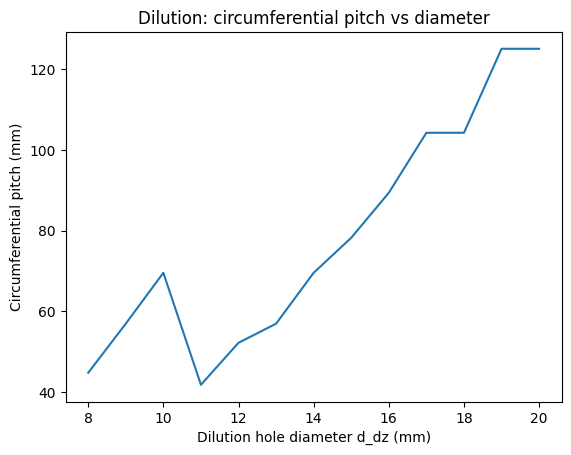

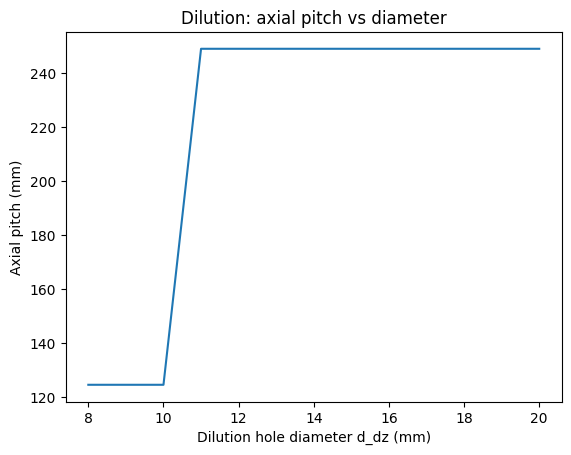

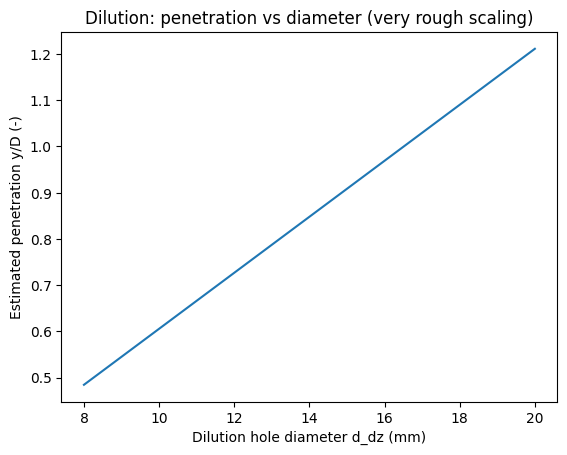

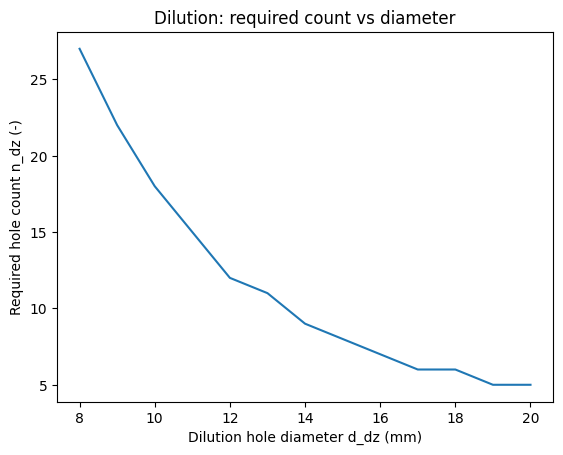

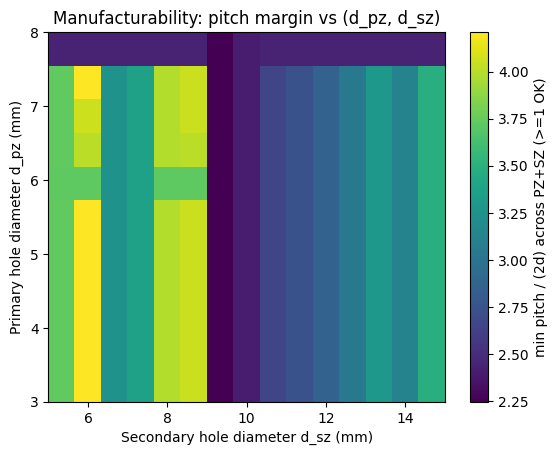


Top 10 (d_pz, d_sz) combos by pitch margin (higher is better):
  margin=4.21 | d_pz=3.0 mm | d_sz=5.7 mm
  margin=4.21 | d_pz=3.5 mm | d_sz=5.7 mm
  margin=4.21 | d_pz=4.0 mm | d_sz=5.7 mm
  margin=4.21 | d_pz=4.5 mm | d_sz=5.7 mm
  margin=4.21 | d_pz=5.0 mm | d_sz=5.7 mm
  margin=4.21 | d_pz=5.5 mm | d_sz=5.7 mm
  margin=4.21 | d_pz=7.5 mm | d_sz=5.7 mm
  margin=4.06 | d_pz=7.0 mm | d_sz=5.7 mm
  margin=4.05 | d_pz=3.0 mm | d_sz=8.6 mm
  margin=4.05 | d_pz=3.5 mm | d_sz=8.6 mm


In [ ]:
import numpy as np
import matplotlib.pyplot as plt

banner("Sweep hole diameters: pitch + penetration vs hole choices")

# --- Sweep ranges (edit as you like)
d_pz_list = np.linspace(3e-3, 8e-3, 11)     # 3–8 mm
d_sz_list = np.linspace(5e-3, 15e-3, 15)    # 5–15 mm
d_dz_list = np.linspace(8e-3, 20e-3, 13)    # 8–20 mm

# --- Pattern assumptions (same logic as Cell 13)
holes_per_row_guess = 16

# --- Use existing computed quantities from previous cells:
# A_h_pz, A_h_sz, A_h_dz, D_liner_eq, L_pz, L_sz, L_dz, rho3, Vj, Vref
check("A_h_pz" in globals(), "Run the liner-hole sizing cell first (needs A_h_pz/A_h_sz/A_h_dz).")

circ = math.pi * D_liner_eq
U_g = Vref
rho_j = rho3
rho_g = rho3
J_base = (rho_j * Vj**2) / (rho_g * U_g**2)  # depends on dp_L and Vref; independent of diameter in this simple model

def compute_zone_metrics(A_req: float, d: float, zone_len: float):
    """Returns: n_total, rows, holes_per_row, circ_pitch, ax_pitch, ok_circ, ok_ax"""
    A_one = math.pi/4.0 * d**2
    n_total = max(1, int(math.ceil(A_req / A_one)))

    n_rows = max(1, int(math.ceil(n_total / holes_per_row_guess)))
    holes_per_row = int(math.ceil(n_total / n_rows))

    pitch_circ = circ / holes_per_row
    pitch_ax = zone_len / n_rows

    ok_circ = pitch_circ >= 2.0 * d
    ok_ax = pitch_ax >= 2.0 * d
    return n_total, n_rows, holes_per_row, pitch_circ, pitch_ax, ok_circ, ok_ax

def penetration_y_over_D(d_dz: float):
    """Very rough dilution penetration scaling used earlier."""
    # y/D ~ K * sqrt(J) * (d/D)
    K_pen = 1.0
    return K_pen * math.sqrt(J_base) * (d_dz / D_liner_eq)

# -------------------------
# Sweep 1D: d_dz vs dilution pitch + penetration
# (Most sensitive and most useful plot)
# -------------------------
d_dz_vals = []
dz_circ_pitch_mm = []
dz_ax_pitch_mm = []
dz_pen = []
dz_n = []

for d in d_dz_list:
    n_total, n_rows, holes_per_row, pitch_circ, pitch_ax, ok_circ, ok_ax = compute_zone_metrics(A_h_dz, float(d), L_dz)
    d_dz_vals.append(float(d) * 1e3)
    dz_circ_pitch_mm.append(pitch_circ * 1e3)
    dz_ax_pitch_mm.append(pitch_ax * 1e3)
    dz_pen.append(penetration_y_over_D(float(d)))
    dz_n.append(n_total)

plt.figure()
plt.plot(d_dz_vals, dz_circ_pitch_mm)
plt.xlabel("Dilution hole diameter d_dz (mm)")
plt.ylabel("Circumferential pitch (mm)")
plt.title("Dilution: circumferential pitch vs diameter")
plt.show()

plt.figure()
plt.plot(d_dz_vals, dz_ax_pitch_mm)
plt.xlabel("Dilution hole diameter d_dz (mm)")
plt.ylabel("Axial pitch (mm)")
plt.title("Dilution: axial pitch vs diameter")
plt.show()

plt.figure()
plt.plot(d_dz_vals, dz_pen)
plt.xlabel("Dilution hole diameter d_dz (mm)")
plt.ylabel("Estimated penetration y/D (-)")
plt.title("Dilution: penetration vs diameter (very rough scaling)")
plt.show()

plt.figure()
plt.plot(d_dz_vals, dz_n)
plt.xlabel("Dilution hole diameter d_dz (mm)")
plt.ylabel("Required hole count n_dz (-)")
plt.title("Dilution: required count vs diameter")
plt.show()

# -------------------------
# Sweep 2D coarse grid: (d_pz, d_sz) -> min pitch constraints
# This quickly shows manufacturability pressure.
# -------------------------
min_pitch_ratio_grid = np.zeros((len(d_pz_list), len(d_sz_list)))  # min( pitch/(2d) ) across PZ+SZ
for i, d_pz in enumerate(d_pz_list):
    for j, d_sz in enumerate(d_sz_list):
        _, _, _, pz_pc, pz_pa, _, _ = compute_zone_metrics(A_h_pz, float(d_pz), L_pz)
        _, _, _, sz_pc, sz_pa, _, _ = compute_zone_metrics(A_h_sz, float(d_sz), L_sz)

        # pitch ratio relative to 2d (>=1 is OK)
        pz_ratio = min(pz_pc/(2*d_pz), pz_pa/(2*d_pz))
        sz_ratio = min(sz_pc/(2*d_sz), sz_pa/(2*d_sz))
        min_pitch_ratio_grid[i, j] = min(pz_ratio, sz_ratio)

# Plot as an image (no explicit colors specified; matplotlib will pick default colormap)
plt.figure()
plt.imshow(
    min_pitch_ratio_grid,
    origin="lower",
    aspect="auto",
    extent=[d_sz_list[0]*1e3, d_sz_list[-1]*1e3, d_pz_list[0]*1e3, d_pz_list[-1]*1e3],
)
plt.colorbar(label="min pitch / (2d) across PZ+SZ (>=1 OK)")
plt.xlabel("Secondary hole diameter d_sz (mm)")
plt.ylabel("Primary hole diameter d_pz (mm)")
plt.title("Manufacturability: pitch margin vs (d_pz, d_sz)")
plt.show()

# Quick textual pick: show top few combos with best pitch margin (manufacturable)
flat = []
for i, d_pz in enumerate(d_pz_list):
    for j, d_sz in enumerate(d_sz_list):
        flat.append((min_pitch_ratio_grid[i, j], float(d_pz), float(d_sz)))
flat.sort(reverse=True, key=lambda x: x[0])

print("\nTop 10 (d_pz, d_sz) combos by pitch margin (higher is better):")
for k in range(10):
    margin, d_pz, d_sz = flat[k]
    print(f"  margin={margin:.2f} | d_pz={d_pz*1e3:.1f} mm | d_sz={d_sz*1e3:.1f} mm")

d_dz = 17mm
d_pz = 8mm
d_sz = 12mm